# Разработка A/B-тестирования и анализ результатов

 В нашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Нас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Мы будем работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Наши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.power import NormalIndPower 
from statsmodels.stats.proportion import proportion_effectsize
from math import ceil
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# Выгружаем данные о сессиях пользователей в переменную sessions_history
sessions_history = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_history.csv')

In [3]:
# Выводим на экран первые пять строк полученного датафрейма
sessions_history.head(5)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитем количество уникальных сессий `session_id`.

- Выведим на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий.

- Изучим таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [4]:
# Подсчёт количества уникальных сессий для каждого пользователя
user_session_count = sessions_history.groupby('user_id')['session_id'].nunique()
user_session_count

user_id
00005FB6A13A6FBE    2
0000B15A18D77ED9    3
0000C4E3A4A571A9    2
000293FAF9E67A81    4
00029C5AE889A6C3    2
                   ..
FFFCDE7746148710    4
FFFDD413285E753F    3
FFFECBA0F2578AB0    2
FFFEDB68228B5F21    5
FFFF4228DF580C3B    3
Name: session_id, Length: 134039, dtype: int64

In [5]:
# Нахождение пользователя с наибольшим количеством сессий
max_sessions_user = user_session_count.idxmax()


# Вывод всех данных для пользователя с наибольшим количеством сессий
user_data = sessions_history[sessions_history['user_id'] == max_sessions_user]
user_data 

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, нам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируем исторические данные и рассчитаем число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты будем считайтать, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Построим линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. 

- Построим отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

In [6]:
sessions_history['session_date']

0         2025-08-15
1         2025-08-15
2         2025-08-15
3         2025-08-15
4         2025-08-15
             ...    
435919    2025-09-17
435920    2025-09-17
435921    2025-09-17
435922    2025-09-17
435923    2025-09-17
Name: session_date, Length: 435924, dtype: object

In [7]:
# Агрегируем данные и рассчитываем количество уникальных пользователей пользователей по дням
daily_users = sessions_history.groupby(sessions_history['session_date'])['user_id'].nunique().reset_index(name='total_users')
daily_users

,session_date,total_users
0,2025-08-11,3919
1,2025-08-12,6056
2,2025-08-13,8489
3,2025-08-14,10321
4,2025-08-15,14065
5,2025-08-16,12205
6,2025-08-17,11200
7,2025-08-18,10839
8,2025-08-19,12118
9,2025-08-20,13514


In [8]:
# Агрегируем данные и рассчитываем количество зарегистрированных пользователей по дням
registered_users = sessions_history[sessions_history['registration_flag'] == 1].groupby(sessions_history['session_date'])['user_id'].nunique().reset_index(name='registered_users')
registered_users

,session_date,registered_users
0,2025-08-11,169
1,2025-08-12,336
2,2025-08-13,464
3,2025-08-14,625
4,2025-08-15,840
5,2025-08-16,916
6,2025-08-17,833
7,2025-08-18,860
8,2025-08-19,831
9,2025-08-20,1008


In [9]:
# Объединяем данные в одну таблицу для дальнейшего построения графика
merged_data = daily_users.merge(registered_users, on='session_date', how='left').fillna(0)
merged_data

,session_date,total_users,registered_users
0,2025-08-11,3919,169
1,2025-08-12,6056,336
2,2025-08-13,8489,464
3,2025-08-14,10321,625
4,2025-08-15,14065,840
5,2025-08-16,12205,916
6,2025-08-17,11200,833
7,2025-08-18,10839,860
8,2025-08-19,12118,831
9,2025-08-20,13514,1008


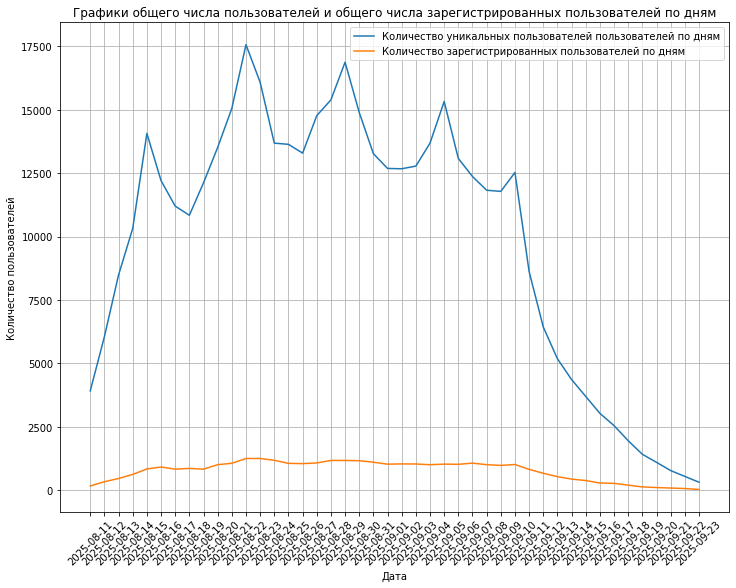

In [10]:
# Строим графики общего числа пользователей и общего числа зарегистрированных пользователей по дням

plt.figure(figsize=(12, 9))
plt.plot(merged_data['session_date'], merged_data['total_users'], label='Количество уникальных пользователей пользователей по дням')
plt.plot(merged_data['session_date'], merged_data['registered_users'], label='Количество зарегистрированных пользователей по дням')
plt.xticks(rotation=45)
plt.title('Графики общего числа пользователей и общего числа зарегистрированных пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.grid(True)
plt.legend()
plt.show()

In [11]:
# Определим долю зарегистрированных пользователей от всех пользователей по дням
merged_data['registration_ratio'] = merged_data['registered_users'] / merged_data['total_users']
merged_data['registration_ratio']

0     0.043123
1     0.055482
2     0.054659
3     0.060556
4     0.059723
5     0.075051
6     0.074375
7     0.079343
8     0.068576
9     0.074589
10    0.070627
11    0.071229
12    0.077913
13    0.086311
14    0.077741
15    0.079013
16    0.072870
17    0.076358
18    0.069579
19    0.078235
20    0.083296
21    0.081041
22    0.081992
23    0.081005
24    0.073595
25    0.067215
26    0.078223
27    0.086440
28    0.085320
29    0.083192
30    0.081031
31    0.095558
32    0.103947
33    0.103608
34    0.100825
35    0.103569
36    0.094327
37    0.106750
38    0.102971
39    0.093089
40    0.097273
41    0.112113
42    0.124542
43    0.100946
Name: registration_ratio, dtype: float64

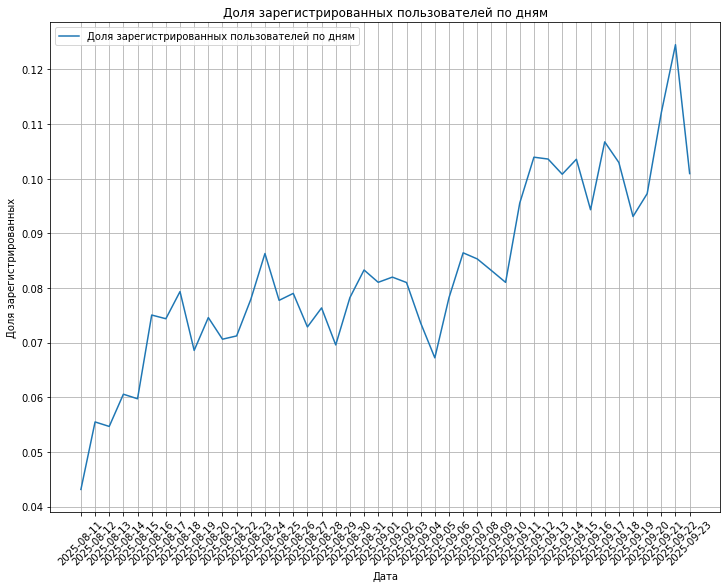

In [12]:
# Строим график доли зарегистрированных пользователей по дням
plt.figure(figsize=(12, 9))
plt.plot(merged_data['session_date'], merged_data['registration_ratio'],label='Доля зарегистрированных пользователей по дням')
plt.xticks(rotation=45)
plt.title('Доля зарегистрированных пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Доля зарегистрированных')
plt.grid(True)
plt.legend()
plt.show()

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

Проанализируем число просмотренных страниц во время первых сессий пользователей. Найдем количество первых сессий для каждого значения количества просмотренных страниц.

- Построим столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

In [13]:
# Определим количество первых сессий для каждого значения количества просмотренных страниц
first_sessions = sessions_history.sort_values(by=['user_id', 'session_date']).groupby('user_id').nth(0) # nth(0) - метод, предназначенный для получения первого элемента итерируемого объекта (с индексом 0)
first_sessions

,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
user_id,,,,,,,,,
00005FB6A13A6FBE,0412A88ADCBDFA14,2025-08-29,2025-08-29 18:02:32,2025-08-29,1,0,3,CIS,iPhone
0000B15A18D77ED9,894EA45DA2B6EFA9,2025-09-04,2025-09-04 14:58:29,2025-09-04,1,0,4,CIS,Android
0000C4E3A4A571A9,D69B851273B70727,2025-09-09,2025-09-09 16:41:53,2025-09-09,1,0,4,CIS,Android
000293FAF9E67A81,51005CC42AB3CDC6,2025-09-01,2025-09-01 19:38:48,2025-09-01,1,0,3,CIS,Android
00029C5AE889A6C3,397A57D41D5B334B,2025-08-19,2025-08-19 16:11:23,2025-08-19,1,0,2,CIS,PC
...,...,...,...,...,...,...,...,...,...
FFFCDE7746148710,61AB969C3574447D,2025-08-15,2025-08-15 12:56:33,2025-08-15,1,0,1,EU,Mac
FFFDD413285E753F,DCAEECF888FCE227,2025-09-07,2025-09-07 19:25:40,2025-09-07,1,0,3,MENA,Android
FFFECBA0F2578AB0,740618A1188E8D08,2025-09-05,2025-09-05 17:57:07,2025-09-05,1,0,3,CIS,Android


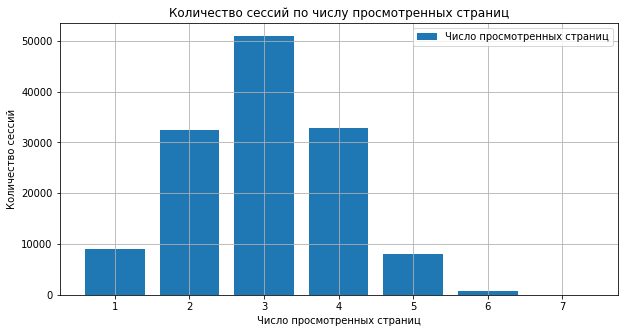

In [14]:
# Подсчитываем количество сессий для каждого количества просмотренных страниц
pages_count = first_sessions['page_counter'].value_counts().reset_index()

pages_count.columns = ['page_counter', 'first_sessions'] # Устанавливает новые имена для столбцов в датафрейме pages_count.
                                                        #'page_counter' — имя, присваиваемое первому столбцу, 'first_sessions' —  имя, присваиваемое второму столбцу

# Строим столбчатую диаграмму, в которой по оси X отображено число просмотренных страниц, по оси Y — количество сессий
plt.figure(figsize=(10, 5))
plt.bar(pages_count['page_counter'], pages_count['first_sessions'],label='Число просмотренных страниц')
plt.title('Количество сессий по числу просмотренных страниц')
plt.xlabel('Число просмотренных страниц')
plt.ylabel('Количество сессий')
plt.grid(True)
plt.legend()
plt.show()

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Построим график со средним значением доли успешных сессий от всех первых сессий пользователей. Данные визуализируем по дням за весь период наблюдения.

In [15]:
# Создадим дополнительный столбец good_session
sessions_history['good_session'] = np.where(sessions_history['page_counter'] >= 4, 1, 0)
sessions_history['good_session']

0         0
1         1
2         1
3         1
4         0
         ..
435919    0
435920    1
435921    1
435922    1
435923    0
Name: good_session, Length: 435924, dtype: int64

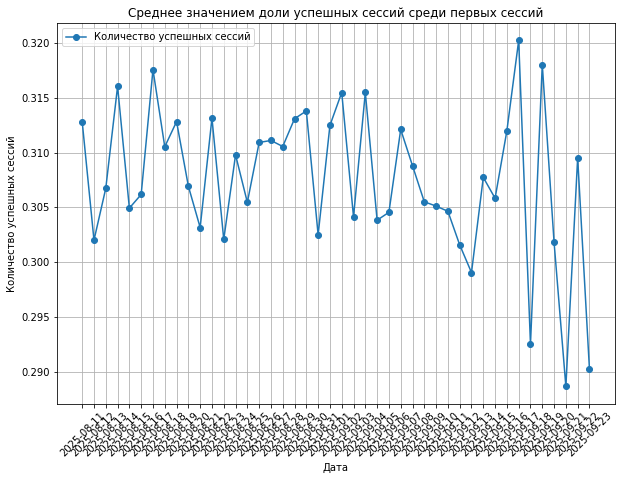

In [16]:
# Рассчитываем долю успешных сессий по дням
average_success_rate = sessions_history.groupby(sessions_history['session_date'])['good_session'].mean()


# Строим график
plt.figure(figsize=(10, 7))
plt.plot(average_success_rate.index, average_success_rate, marker='o',label='Количество успешных сессий') # average_success_rate.index — индекс серии average_success_rate, содержащий уникальные значения, по которым были сгруппированы данные
                                                                       # это даты, по которым рассчитывается средний процент успешных сессий среди первых сессий пользователей

plt.xticks(rotation=45) 
plt.title('Cреднее значением доли успешных сессий среди первых сессий')
plt.xlabel('Дата')
plt.ylabel('Количество успешных сессий')
plt.legend()
plt.grid(True)
plt.show()

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки

In [17]:
# Задаём параметры
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p1 = 0.3 # Базовый уровень доли
mde = p1 * 0.03 # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p1, p1 + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности A/B-теста

Используем данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитаем длительность теста, разделив одно на другое.

- Рассчитаем среднее количество уникальных пользователей приложения в день.

- Определим длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. 

In [18]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil((sample_size*2)/ avg_daily_users) # sample_size*2 поскольку у нас две выборки

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считаем и сохраним в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитаем и выведим на экран процентную разницу в количестве пользователей в группах A и B. Построим визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуемся формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [19]:
# Выгружаем итрорические данные о сессиях пользователей в переменную sessions_test_part
sessions_test_part = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test_part.csv')
sessions_test_part

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B
...,...,...,...,...,...,...,...,...,...,...,...
3125,02A3BA5F727BC3C9,7D4427384463A16E,2025-10-14,2025-10-14 14:52:26,2025-10-14,1,0,4,MENA,Android,B
3126,A7E51F39427F03A5,290910138655DD03,2025-10-14,2025-10-14 19:15:18,2025-10-14,1,0,2,CIS,PC,B
3127,78DDBD077D61EEDB,C10E073BFF1FAF0C,2025-10-14,2025-10-14 16:07:20,2025-10-14,1,0,2,EU,iPhone,B
3128,B44E0A30E8ED1AFC,7B404F7021711E5D,2025-10-14,2025-10-14 17:41:01,2025-10-14,1,0,3,EU,Mac,B


In [20]:
# Расчёт количества уникальных пользователей в группе A и В
unique_users_group_A = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'].nunique()
unique_users_group_A

1477

In [21]:
unique_users_group_B = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'].nunique()
unique_users_group_B

1466

In [22]:
# Рассчитаем и выведим на экран процентную разницу в количестве пользователей в группах 
percentage_difference = 100 * abs(unique_users_group_A - unique_users_group_B) / unique_users_group_A # С помощью функции abs() рассчитываем модуль числа
percentage_difference

0.7447528774542993

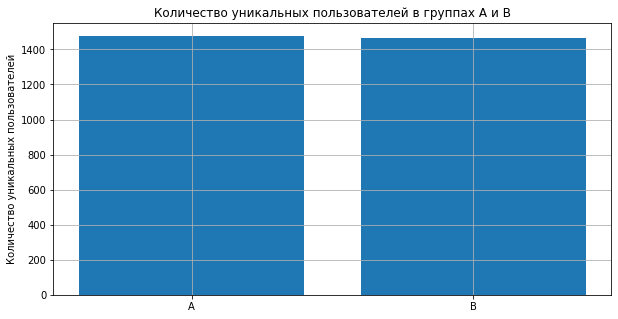

In [23]:
# Расчёт количества уникальных пользователей в группе A и В
unique_users_group_A = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'].nunique()
unique_users_group_B = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'].nunique()

plt.figure(figsize=(10, 5))
plt.bar(
    ['A', 'B'],
    [unique_users_group_A, unique_users_group_B]
)
plt.title('Количество уникальных пользователей в группах A и B')
plt.ylabel('Количество уникальных пользователей')
plt.grid(True)
plt.show()

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитаем количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [24]:
# Рассчитаем количество пользователей, которые встречаются одновременно в группах A и B

In [25]:
# Получаем списки ID пользователей для каждой группы
users_A = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'].tolist()
users_B = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'].tolist()

# Преобразуем в множества и находим пересечение
common_users = set(users_A) & set(users_B)
number_of_common_users = len(common_users)

print(f"Количество пользователей, встречающихся одновременно в группах A и B: {number_of_common_users}")

Количество пользователей, встречающихся одновременно в группах A и B: 0


#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Построим две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

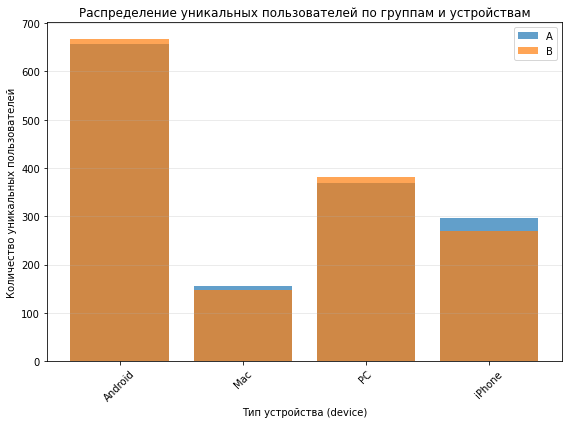

In [26]:
# Группируем данные по test_group и device, затем считаем уникальные user_id
unique_users_by_device = sessions_test_part.groupby(['test_group', 'device'])['user_id'].nunique()

# Преобразуем результат в DataFrame для удобства
df_plot = unique_users_by_device.reset_index()

plt.figure(figsize=(8, 6))

# Строим диаграмму
for test_group in df_plot['test_group'].unique():
    subset = df_plot[df_plot['test_group'] == test_group]
    plt.bar(subset['device'], subset['user_id'], 
            label=test_group, alpha=0.7)

plt.xlabel('Тип устройства (device)')
plt.ylabel('Количество уникальных пользователей')
plt.title('Распределение уникальных пользователей по группам и устройствам')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show() 

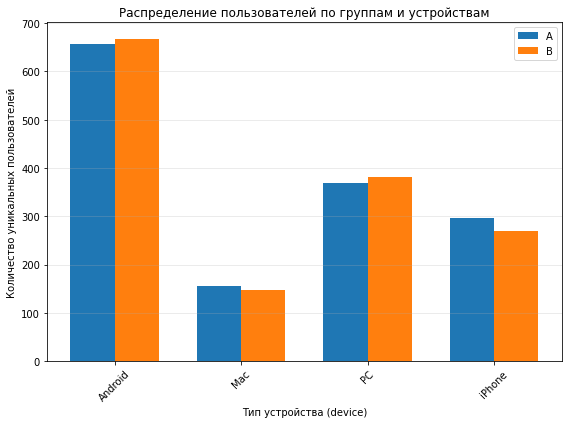

In [27]:
# pivot — чтобы сразу получить удобную таблицу
df_pivot = df_plot.pivot(index='device', columns='test_group', values='user_id')

devices = df_pivot.index
x = np.arange(len(devices))  # позиции по X
width = 0.35  # ширина столбца

plt.figure(figsize=(8, 6))

plt.bar(x - width/2, df_pivot['A'], width, label='A')
plt.bar(x + width/2, df_pivot['B'], width, label='B')

plt.xlabel('Тип устройства (device)')
plt.ylabel('Количество уникальных пользователей')
plt.title('Распределение пользователей по группам и устройствам')

plt.xticks(x, devices, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедимся, что пользователи равномерно распределены по регионам.

Построим две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

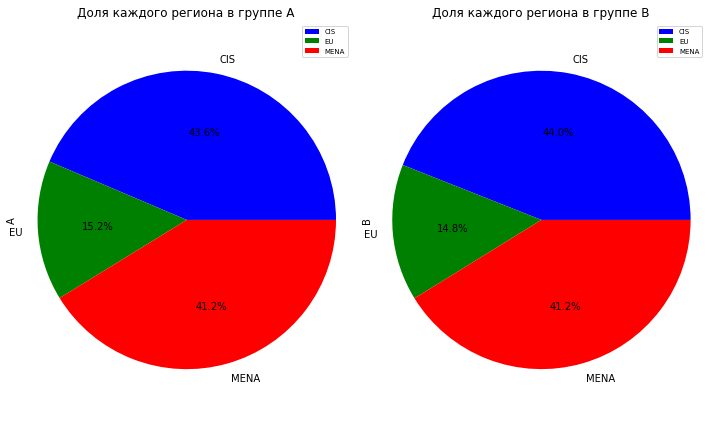

In [28]:
# Группируем данные по test_group и region, и считаем уникальные user_id
unique_users_by_device = sessions_test_part.groupby(['test_group', 'region'])['user_id'].nunique().unstack('region')

plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
unique_users_by_device.loc['A'].plot(kind='pie', autopct='%1.1f%%', colors=['blue', 'green', 'red', 'purple'])
plt.title('Доля каждого региона в группе A')
plt.axis('equal')
plt.legend(fontsize=7)

plt.subplot(1, 2, 2)
unique_users_by_device.loc['B'].plot(kind='pie', autopct='%1.1f%%', colors=['blue', 'green', 'red', 'purple'])
plt.title('Доля каждого региона в группе B')
plt.axis('equal')
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа, мы видим, что количество уникальных пользователей в группах А и В различается на 11 человек (в группе А- 1477 человек, в группе В- 1466 человек), что не критично для дальнейшего исследования.
Выборки групп А и В являются независимыми, поскольку общих значений не выявлено, что является одним из условий проведения A/B-теста.
Так же исходя, из данных графика 'Доля каждого типа устройства для пользователей из группы A' и 'Доля каждого типа устройства для пользователей из группы В', мы видим, что значения долей типов устройств незначительно различаются, что говорит о том, что они сопоставимы между собой и сохраняется равномерное распределние пользователей по типам устройств. Аналогичным образом, в диаграммах долей регионов каждой из групп.
Таким образом, исходя из полученных данных, мы можем предположить, что весьма корректно проходит A/B-тест.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у нас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считаем и сохраним в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [29]:
# Выгружаем итрорические данные о сессиях пользователей в переменную sessions_test
sessions_test = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test.csv')
sessions_test

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B
...,...,...,...,...,...,...,...,...,...,...,...
100000,CF77C27B238C1BE3,0F7BC9B33685377C,2025-10-22,2025-10-22 19:01:50,2025-10-20,3,0,3,MENA,Android,A
100001,D7ED66C581409AC2,26C4475005E70F47,2025-10-17,2025-10-17 22:12:38,2025-10-17,1,0,5,CIS,PC,A
100002,E7EA2D51238020C6,9B9CDE6A612CBD73,2025-10-24,2025-10-24 14:54:07,2025-10-14,2,0,3,MENA,PC,B
100003,8A6FEFD7F34C5DA1,37291EC27106EF9D,2025-10-18,2025-10-18 00:05:10,2025-10-14,3,0,4,EU,Android,B


In [30]:
# Создадим дополнительный столбец good_session
sessions_test['good_session'] = np.where(sessions_test['page_counter'] >= 4, 1, 0)
sessions_test['good_session']

0         0
1         0
2         0
3         0
4         0
         ..
100000    0
100001    1
100002    0
100003    1
100004    0
Name: good_session, Length: 100005, dtype: int64

#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


В качестве основной метрики можно взять долю успешных первых сессий.

В качестве нулевой гипотезы можно выдвинуть предположение о том, что доля успешныцх первых сессий до нововедений (разработка нового алгоритма, демонстриующего более интересный контент) и после - не изменится.

В качестве альтернативной гипотезы можно выдвинуть предположение о том, что доля успешныцх первых сессий после нововедений (разработка нового алгоритма, демонстриующего более интересный контент) будет больше доли успешныцх первых сессий до нововедений. 

Показатели прокси-метрики: время, проведенное на сайте, увеличение количества скачиваний приложения, повышение количества зарегистрированных пользователей, рост числа платных подписок (возможность смотреть ленту без рекламы).

Показатели берьерных-метрик: частота сбоев или ошибок приложения, скорость выгрузки страниц.

#### 4.3. Сравнение доли успешных сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используем созданный на первом шаге задания столбец `good_session` и рассчитаем долю успешных первых сессий для выборок A и B, а также разницу в этом показателе.

In [31]:
# Определяем группу А и В
group_A = sessions_test[sessions_test['test_group'] == 'A']

In [32]:
group_B = sessions_test[sessions_test['test_group'] == 'B']

In [33]:
# Рассчитаем долю успешных первых сессий для выборок A и B
success_rate_A = group_A['good_session'].sum() / len(group_A)
success_rate_A 

0.3077233557344958

In [34]:
success_rate_B = group_B['good_session'].sum() / len(group_B)
success_rate_B

0.31828992745867524

In [35]:
# Считаем разницу между долями
difference = success_rate_A - success_rate_B

# Выводим результаты
print(f'Доля успешных первых сессий в группе A: {success_rate_A:.3f}')
print(f'Доля успешных первых сессий в группе B: {success_rate_B:.3f}')
print(f'Разница в доле успешных сессий между группами A и B: {difference:.3f}')

Доля успешных первых сессий в группе A: 0.308
Доля успешных первых сессий в группе B: 0.318
Разница в доле успешных сессий между группами A и B: -0.011


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитаем, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведим на экран полученное значение p-value и свои выводы о статистической значимости. 

In [36]:
# Определим размер выборок А и В
n_a, n_b = sessions_test[sessions_test['test_group'] == 'A'].shape[0],  sessions_test[sessions_test['test_group'] == 'B'].shape[0] 

# Определим количество 'успехов' в группах A и В
m_a = sessions_test[(sessions_test['test_group'] == 'A') & (sessions_test['good_session'] == 1)].shape[0]
m_b = sessions_test[(sessions_test['test_group'] == 'B') & (sessions_test['good_session'] == 1)].shape[0] 

In [37]:
p_a, p_b = m_a/n_a, m_b/n_b # рассчитываем доли успехов для каждой группы: A и B
p_a, p_b

(0.3077233557344958, 0.31828992745867524)

In [38]:
print(f'n_a={n_a}, n_b={n_b}')

print(f'm_a={m_a}, m_b={m_b}')

print(f'p_a={p_a}, p_b={p_b}')

if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10):
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')

n_a=49551, n_b=50454
m_a=15248, m_b=16059
p_a=0.3077233557344958, p_b=0.31828992745867524
Предпосылка о достаточном количестве данных выполняется!


In [39]:
# Проводим Z-тест пропорций

alpha = 0.05 # На каком уровне значимости проверяем гипотезу о равенстве вероятностей

stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller' # так как H_1: p_a < p_b
)


if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest} > {alpha}')
    print('Не имеем достаточных оснований для отклонения нулевой гипотезы (не удалось отвергнуть)')
else:
    print(f'pvalue={p_value_ztest} < {alpha}')
    print('Отвергаем нулевую гипотезу (𝐻0)')

pvalue=0.0001574739988036123 < 0.05
Отвергаем нулевую гипотезу (𝐻0)


#### 4.5. Вывод по результатам A/B-эксперимента

Таким образом, в ходе исследования мы взяли в качестве основной метрики долю успешных первых сессий пользователей приложения.
Нулевая гипотеза- доля успешныцх первых сессий до нововедений (разработка нового алгоритма, демонстриующего более интересный контент) и после - не изменится.
Альтернативная гипотеза-  доля успешныцх первых сессий после нововедений (разработка нового алгоритма, демонстриующего более интересный контент) будет больше доли успешных первых сессий до нововедений.
Исходя из расчетов выше, необходимый размер выборки для проведения А/В-теста 41040 пользователь, а длительность 9 дней.
Доля успешных первых сессий для выборки A составляет 0.308 (31%), для выборки В - 0.318 (32%).
p-value Z-тест пропорций  = 0.0001574739988036123.( pvalue < 0.05, поэтому нулевая гипотеза  о том, что доля успешныцх первых сессий до нововедений и после - не изменится, не находит подтверждения). Поэтому мы можем принять альтернативную гипотизу о том,  что доля успешныцх первых сессий после нововедений (разработка нового алгоритма, демонстриующего более интересный контент) будет больше доли успешныцх первых сессий до нововедений.
Учитывая все вышеизложенные факты, мы можем сделать вывод о рациональности внедрения нововедения в приложении.